## Importación de Librerías

En esta sección se importan las librerías necesarias para el análisis y limpieza de datos.

In [33]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.conftest import observed
from sklearn.linear_model import LinearRegression

os.makedirs('../graficas', exist_ok=True)

## Carga y Exploración Inicial

Se carga el dataset y se realiza una inspección inicial.

In [34]:
df = pd.read_csv('../datasets/housing.csv')

In [35]:
#Visualizar datos preliminares del dataset

print('Dataset cargado:', df.shape)
print('\nColumnas del dataset:')
print(list(df.columns))
print('\nTipo de datos:')
print(df.dtypes)

Dataset cargado: (20640, 10)

Columnas del dataset:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']

Tipo de datos:
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity           str
dtype: object


In [36]:
#buscar valores nulos
print('Busqueda de datos nulos:')
print(df.isnull().sum())
print()
print(df['ocean_proximity'].value_counts())
print()
print('\nPorcentaje en Ocen_proximity')
print((df['ocean_proximity'].value_counts() / len(df) *100).round(2))

Busqueda de datos nulos:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


Porcentaje en Ocen_proximity
ocean_proximity
<1H OCEAN     44.26
INLAND        31.74
NEAR OCEAN    12.88
NEAR BAY      11.09
ISLAND         0.02
Name: count, dtype: float64


In [37]:
#Rellenar los nulos

total_bedrooms_mediana = df['total_bedrooms'].median()
df['total_bedrooms'] = df['total_bedrooms'].fillna(total_bedrooms_mediana)
print(f'Cantidad de nulos luego de rellenar con mediana: {df['total_bedrooms'].isnull().sum()}')

Cantidad de nulos luego de rellenar con mediana: 0


In [38]:
#eliminar datos duplicados
print('Eliminar datos duplicados')
df.drop_duplicates()
print('Nueva forma del dataset sin duplicados', df.shape)

Eliminar datos duplicados
Nueva forma del dataset sin duplicados (20640, 10)


In [39]:
##Modelo regresion lineal simple
#X=variable que se usara para entrenar el modelo
#y=variable que se usara para predecir

X_simple = df[['median_income']] # Se agregan doble brackets porque scikit-learn siempre pedira un dataframe y no una columna.
y = df['median_house_value']

modelo_simple = LinearRegression()
modelo_simple.fit(X_simple, y)

#identificando el coeficiente del modelo con el objetivo de saber si el modelo esta aprendiendo o no.
print('Pendiente: ', round(modelo_simple.coef_[0], 2))
print('Intercepto:', round(modelo_simple.intercept_, 2))

ingreso_nuevo = pd.DataFrame([[8.0]], columns=['median_income'])
prediccion = modelo_simple.predict(ingreso_nuevo)
print()
print(f"Para un ingreso promedio de 8.0 ($80,000), el modelo predice: ${prediccion[0]:,.2f}")

Pendiente:  41793.85
Intercepto: 45085.58

Para un ingreso promedio de 8.0 ($80,000), el modelo predice: $379,436.37


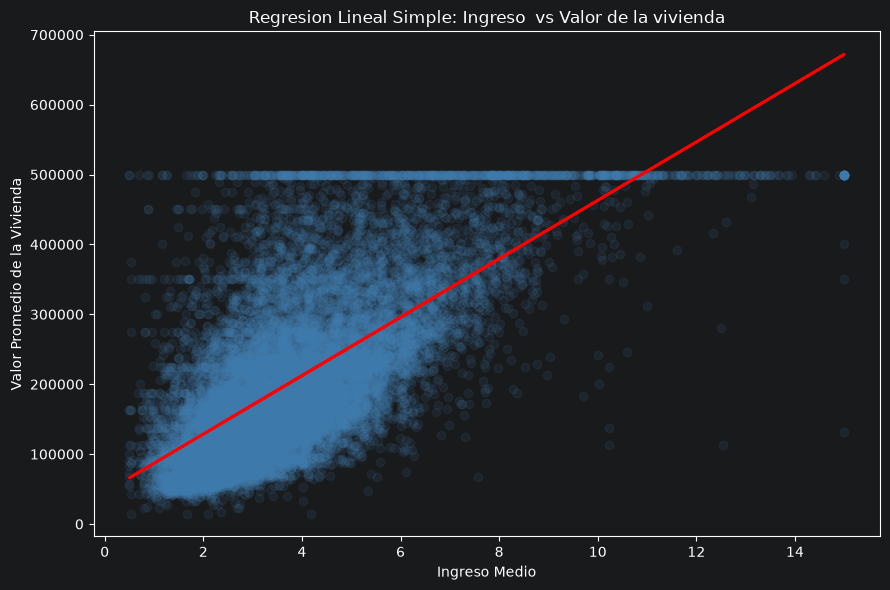

In [40]:
#Visualizacion de la regresion lineal

plt.figure(figsize=(9,6))
plt.scatter(df['median_income'], df['median_house_value'], alpha=0.1, color='steelblue')
plt.plot(df['median_income'], modelo_simple.predict(X_simple), color='red', linewidth=2)
plt.title('Regresion Lineal Simple: Ingreso  vs Valor de la vivienda')
plt.xlabel('Ingreso Medio')
plt.ylabel('Valor Promedio de la Vivienda')
plt.tight_layout() #se utiliza para que la grafica o imagen no se distorcione

plt.savefig('../graficas/01_linear_regression.png')
plt.show()